# MLflow Hyperparameter Tuning

`Hyperparameter Tuning`:

- the process to **select the optimal configuration settings** for a machine learning model before the training process begins in order to **maximize its predictive accuracy**.


## Environment

In [1]:
from src.tracking import tracking_uri
import sys
from pathlib import Path

import mlflow
import torch

# data
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

# mlflow instance
mlflow.set_tracking_uri(tracking_uri())

# print versions and mlflow
print("torch     ", torch.__version__)
print("cuda      ", torch.cuda.is_available())
print("tracking  ", tracking_uri())
print("experiments", [e.name for e in mlflow.search_experiments()])

torch      2.13.0+cpu
cuda       False
tracking   http://mlflow:5000
experiments ['yolo-plate-detection-sweep', 'yolo-plate-detection', '/workspace/runs', 'Default']


## Split data

Define same split before sweep.

- sweep results are comparable based on the same split


In [2]:
from src.data_loader import build_split, verify_split, write_data_yaml

# limit for fast smoke run; e.g. 200
LIMIT = None  # unlimit
# LIMIT = 200  # limit 200

# random seed
SEED = 0

# print split
print(build_split(RAW, PROCESSED, val_fraction=0.2, limit=LIMIT, seed=SEED))
print(verify_split(PROCESSED))

names = (RAW / "classes.txt").read_text().split()
data_yaml = write_data_yaml(ROOT / "configs" / "data.yaml", PROCESSED, names)
print(data_yaml.read_text())

{'train': 445, 'val': 111, 'orphan_images': 0, 'orphan_labels': 0}
{'train': 445, 'val': 111}
path: /workspace/data/processed
train: train/images
val: val/images
nc: 1
names: ['car_plate']



## Define sweep (Grid search)

`Grid search`:

- Exhaustively tests every single **combination in a predefined matrix of values**.


In [3]:
import yaml

# experiment name
EXPERIMENT = "yolo-plate-detection-sweep"

# load base param config
base_cfg = yaml.safe_load((ROOT / "configs" / "train.yaml").read_text())
base_cfg["project"] = str(ROOT / base_cfg["project"])

# count the split; shared by the run directory, the run name and the onnx file
n_images = sum(len(list((PROCESSED / s / "images").iterdir())) for s in ("train", "val"))

# cpu today, cuda once a GPU is available -- train.yaml drives it
DEVICE = "cpu" if base_cfg["device"] in ("cpu", None) else "gpu"

# tune-<device>-<images>img-<imgsz>px-ep<epochs>
def run_id(epochs):
    return f"tune-{DEVICE}-{n_images}img-{base_cfg['imgsz']}px-ep{epochs}"

# define grid
GRID = [{"epochs": e, "name": run_id(e)} for e in (10, 20, 30)]

print(f"experiment {EXPERIMENT}")
for g in GRID:
    print(" ", g)

experiment yolo-plate-detection-sweep
  {'epochs': 10, 'name': 'tune-cpu-556img-640px-ep10'}
  {'epochs': 20, 'name': 'tune-cpu-556img-640px-ep20'}
  {'epochs': 30, 'name': 'tune-cpu-556img-640px-ep30'}


## Run sweep

- Each config in grid becomes its own mlflow run
- log with mlflow


In [4]:
from src.tracking import run_sweep

# run sweep with helper function
results = run_sweep(
    grid=GRID,
    base_cfg=base_cfg,
    data_yaml=data_yaml,
    processed_dir=PROCESSED,
    raw_dir=RAW,
    experiment=EXPERIMENT,
    # same stem as the run directory, so mlflow and disk agree
    run_name=lambda cfg: run_id(cfg["epochs"]),
)

for r in results:
    print(r)


[1/3] tune-cpu-556img-640px-ep10  {'epochs': 10, 'name': 'tune-cpu-556img-640px-ep10'}
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.13.0+cpu CPU (Intel Core 5 120U)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspace/configs/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, 

## List experiment runs

List emperiment runs for comparison.


In [5]:
from src.tracking import compare_runs

table = compare_runs(EXPERIMENT)
table

,mlflow.runName,epochs,imgsz,data.train_images,metrics/mAP50B,metrics/mAP50-95B,metrics/precisionB,metrics/recallB
0,tune-cpu-556img-640px-ep30,30,640,445,0.979341,0.814850,0.963826,0.974138
1,tune-cpu-556img-640px-ep20,20,640,445,0.993786,0.823185,0.982869,0.989193
2,tune-cpu-556img-640px-ep10,10,640,445,0.990606,0.793533,0.977823,0.939655
3,tune-cpu-10img-640px-ep30,30,640,8,0.745000,0.373487,0.003333,1.000000
4,tune-cpu-10img-640px-ep20,20,640,8,0.995000,0.398867,0.003333,1.000000
5,tune-cpu-10img-640px-ep10,10,640,8,0.023596,0.009573,0.003333,1.000000
6,cpu-556img-ep10-640px,10,640,None,0.014390,0.009070,0.020250,0.017240
7,cpu-ep20-640px,20,640,None,0.979090,0.768920,0.955740,0.965520
8,cpu-ep10-640px,10,640,445,0.989509,0.790681,0.957315,0.966699
9,cpu-ep30-640px,30,640,160,0.974240,0.827379,0.969192,0.906977


visualize historical metrics


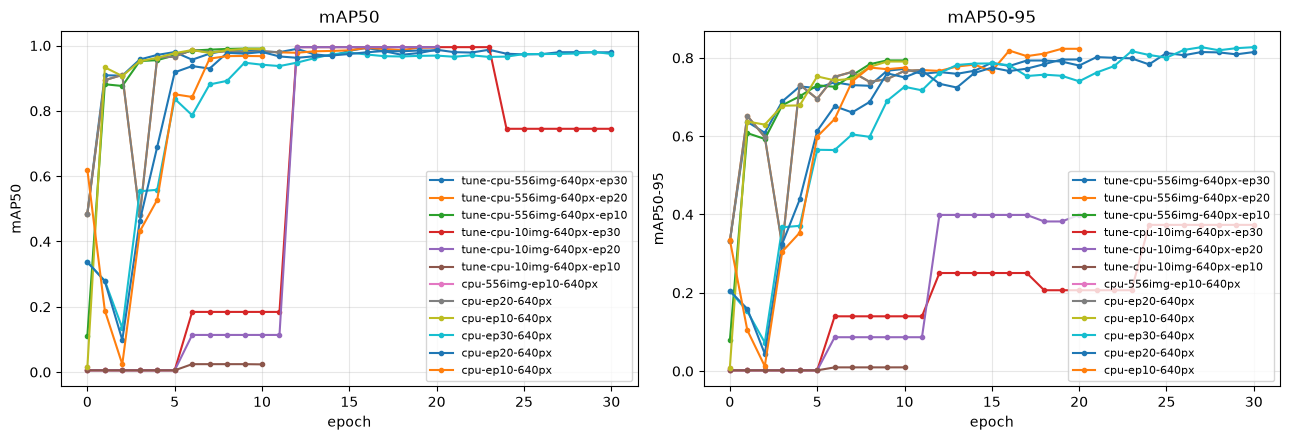

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

# get historical run metrics
client = mlflow.tracking.MlflowClient()
experiment = mlflow.get_experiment_by_name(EXPERIMENT)
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for _, row in runs.iterrows():
    label = row["tags.mlflow.runName"]
    for ax, metric in zip(axes, ("metrics/mAP50B", "metrics/mAP50-95B")):
        history = client.get_metric_history(row["run_id"], metric)
        if history:
            ax.plot([p.step for p in history], [
                    p.value for p in history], marker="o", ms=3, label=label)

for ax, metric in zip(axes, ("mAP50", "mAP50-95")):
    ax.set_xlabel("epoch")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
# Cost against benefit -- more epochs always helps a little, so the question is
# whether the gain justifies the minutes.
cols = ["tags.mlflow.runName", "params.epochs", "metrics.metrics/mAP50-95B", "metrics.elapsed_seconds"]
cost = runs[[c for c in cols if c in runs.columns]].copy()
cost.columns = [c.split(".", 1)[-1] for c in cost.columns]
# sort by epochs
cost = cost.sort_values("epochs", key=lambda s: s.astype(int))
cost["min_per_0.01_mAP"] = (
    cost["elapsed_seconds"] / 60 / (cost["metrics/mAP50-95B"] * 100)
).round(2)
cost

,mlflow.runName,epochs,metrics/mAP50-95B,elapsed_seconds,min_per_0.01_mAP
2,tune-cpu-556img-640px-ep10,10,0.793533,1878.401598,0.39
5,tune-cpu-10img-640px-ep10,10,0.009573,45.476127,0.79
6,cpu-556img-ep10-640px,10,0.009070,NaN,NaN
8,cpu-ep10-640px,10,0.790681,1516.776277,0.32
11,cpu-ep10-640px,10,0.775026,547.283441,0.12
7,cpu-ep20-640px,20,0.768920,NaN,NaN
4,tune-cpu-10img-640px-ep20,20,0.398867,77.110714,0.03
1,tune-cpu-556img-640px-ep20,20,0.823185,4357.331578,0.88
10,cpu-ep20-640px,20,0.795853,1239.997456,0.26
3,tune-cpu-10img-640px-ep30,30,0.373487,135.326062,0.06


Browse the runs at http://127.0.0.1:5000.

## Export the best model

Pick the run with the highest mAP50-95, then export its weights.


In [17]:
METRIC = "metrics/mAP50-95B"

# the experiment accumulates runs from every past sweep, and older ones may have
# used a different split or imgsz. rank only the runs this GRID just produced.
# mlflow's filter_string supports AND but not OR, so match the names in pandas.
wanted = [g["name"] for g in GRID]

experiment = mlflow.get_experiment_by_name(EXPERIMENT)
ranked = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=[f"metrics.`{METRIC}` DESC"],
)
ranked = ranked[ranked["params.name"].isin(wanted)]

best_run = ranked.iloc[0]
# get best run directory
best_name = best_run["params.name"]

print(f"compared  {len(ranked)} of {len(wanted)} grid runs")
print(f"run       {best_run['tags.mlflow.runName']}")
print(f"dir       {best_name}")
print(f"epochs    {best_run['params.epochs']}")
print(f"mAP50-95  {best_run[f'metrics.{METRIC}']:.4f}")

compared  3 of 3 grid runs
run       tune-cpu-556img-640px-ep20
dir       tune-cpu-556img-640px-ep20
epochs    20
mAP50-95  0.8232


Export model.


In [20]:
import shutil

from ultralytics import YOLO

# load the winning run's weights
best = YOLO(str(ROOT / "runs" / best_name / "weights" / "best.pt"))

# imgsz must match training
imgsz = int(best_run["params.imgsz"])
exported = Path(best.export(format="onnx", imgsz=imgsz, opset=12, simplify=True))

MODELS = ROOT / "models"
MODELS.mkdir(exist_ok=True)
onnx_path = MODELS / f"{best_name}.onnx"
shutil.move(str(exported), onnx_path)

print(onnx_path)
print(f"{onnx_path.stat().st_size / 1e6:.1f} MB")

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.13.0+cpu CPU (Intel Core 5 120U)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/workspace/runs/tune-cpu-556img-640px-ep20/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)

ONNX: starting export with onnx 1.22.0 opset 12...
ONNX: slimming with onnxslim 0.1.95...
ONNX: export success ✅ 1.2s, saved as '/workspace/runs/tune-cpu-556img-640px-ep20/weights/best.onnx' (10.1 MB)

Export complete (1.6s)
Results saved to /workspace/runs/tune-cpu-556img-640px-ep20/weights/best.onnx
Predict:         yolo predict task=detect model=/workspace/runs/tune-cpu-556img-640px-ep20/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/workspace/runs/tune-cpu-556img-640px-ep20/weights/best.onnx imgsz=640 data=/workspace/configs/data.yaml  
Visualize:       https://netron.app
/workspace/models/tune-cpu-556img-640px-ep20.onnx
10.6 MB


Export metadata file.


In [19]:
import json

# the graph carries neither class names nor imgsz; the predictor needs both
sidecar = onnx_path.with_suffix(".metadata.json")
sidecar.write_text(json.dumps({
    "imgsz": imgsz,
    "names": [best.names[i] for i in sorted(best.names)],
}, indent=2))

print(sidecar.read_text())

{
  "imgsz": 640,
  "names": [
    "car_plate"
  ]
}
